# 2D CNN: re-evaluation

Re-run of `cnn_2d.ipynb` (originally `testModells.ipynb`).

**Same as the original:** displacement-vector windows as a 25 × 25 × 2 "image"; Conv2D(16) → MaxPool → Conv2D(32) → MaxPool → Dense(256) → Dropout 0.5 → softmax; Adam, batch size 2, 50 epochs.

**Different from the original:** the original passed its test set as `validation_data`, on a dataset that no longer exists. Here training runs a fixed 50 epochs with no validation data, and the model is scored with the shared protocol below.

**Evaluation protocol (shared by every `reeval_*` notebook, see `src/reeval_common.py`):**

- Data: `data/keypoint_sequences.csv`, 41 Kinect recordings that survived; the larger folder the thesis notebooks used is lost.
- 6 classes, as in the thesis models: `squat_front` and `squat_side` are merged into `squat`.
- Stratified 5-fold cross-validation over **recordings**, repeated with 3 shuffles (15 splits). All windows of a recording are on the same side of every split.
- Nothing from a test fold is used for training, hyperparameter search or early stopping.
- Reported per split: window accuracy, macro F1, accuracy after a majority vote per recording (what the real-time system does), and a majority-class baseline.
- The spread across splits is shown as ± one standard deviation. Splits share recordings, so this understates the true uncertainty; with 41 recordings, differences of a few points are not meaningful.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import reeval_common as rc

records = rc.load_recordings()
table = rc.recordings_table(records)
table.groupby("label").agg(recordings=("rec_id", "count"), frames=("n_frames", "sum"))

,recordings,frames
label,,
bent-over_rows,6,456
biceps,6,456
latheral_raises,6,455
rdl,6,455
shoulder_press,6,456
squat,11,836


In [2]:
X, y, groups = rc.displacement_windows(records)
print("windows:", X.shape, "(windows, steps, keypoints, dx/dy)")
pd.Series(y).value_counts().rename("windows").to_frame()

windows: (121, 25, 25, 2) (windows, steps, keypoints, dx/dy)


,windows
squat,33
bent-over_rows,18
biceps,18
shoulder_press,18
latheral_raises,17
rdl,17


In [3]:
import keras
from keras import layers

print("keras", keras.__version__)


def build_cnn():
    model = keras.Sequential([
        keras.Input(shape=(rc.WINDOW, 25, 2)),
        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(len(rc.CLASSES), activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def fit_predict(X_train, y_train, groups_train, X_test, seed):
    keras.utils.set_random_seed(seed)
    model = build_cnn()
    model.fit(X_train, rc.one_hot(y_train), batch_size=2, epochs=50, verbose=0)
    return np.array(rc.CLASSES)[model.predict(X_test, verbose=0).argmax(axis=1)]


result = rc.evaluate(
    fit_predict, X, y, groups, rc.recording_splits(groups, records),
    model="2D CNN", variant="windows", split="recording-level 5-fold × 3",
    features="displacement windows (25 × 25 × 2)", params="Conv 16-32, Dense 256, Adam, batch 2, 50 epochs",
)
result["environment"]["keras"] = keras.__version__
rc.save_results(result, "cnn_2d")
rc.summary_table([result])

keras 3.15.1


,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,2D CNN,windows,recording-level 5-fold × 3,121,15,71.0% ± 11.2%,68.3% ± 10.8%,74.4% ± 14.1%,27.1%


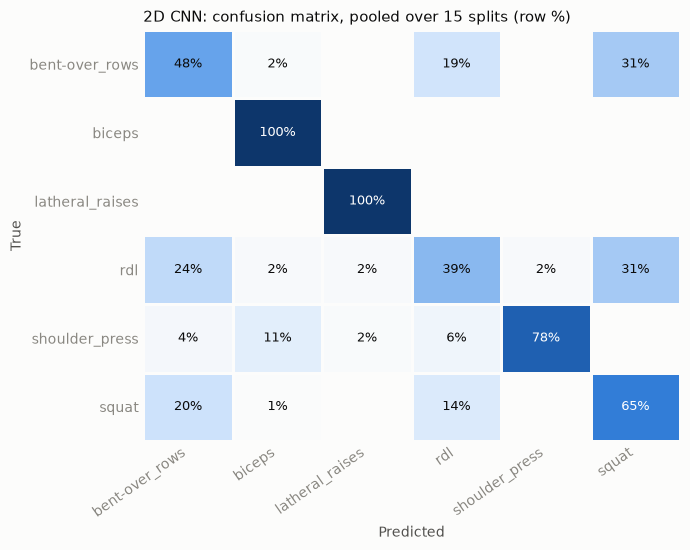

In [4]:
rc.plot_confusion(result, "2D CNN: confusion matrix, pooled over 15 splits (row %)", "cnn_2d_confusion.png");